In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import seaborn as sns
import koreanize_matplotlib
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import gower
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
# 모든 열 다 보기
pd.set_option('display.max_columns', None)

# 너비 제한 없애기 (길게 나올 경우 줄바꿈 없이 한 줄에 표시)
pd.set_option('display.width', None)

In [3]:
data = pd.read_csv(r"C:\Users\jeong\happycircuit\data\real_final_dataset.csv",encoding = "utf-8")

In [4]:
# 사용할 변수 리스트 정의
selected_columns = [
    '시도교육청', '위도', '경도', '이용인원', '1학년 학생수','학교명','시군구',
    '1학년 학급당 학생수', '2학년 학생수', '2학년 학급당 학생수', '3학년 학생수', '3학년 학급당 학생수',
    '4학년 학생수', '4학년 학급당 학생수', '5학년 학생수', '5학년 학급당 학생수', '6학년 학생수',
    '6학년 학급당 학생수', '특수학급 학생수', '특수학급 학급당 학생수', '학생수(계)',
    '학급당 학생수(계)', '교사수', '수업교원 1인당 학생수', '다문화자녀수', '2023_총수입금액(백만원)',
    '교지면적(m)', '학생1인당교지면적', '이용비율'
]

# 원본 데이터에서 선택
data = data[selected_columns].copy()


In [5]:
# 데이터프레임 전체 결측치 확인
data.isnull().sum()

시도교육청               0
위도                  0
경도                  0
이용인원                0
1학년 학생수             0
학교명                 0
시군구                53
1학년 학급당 학생수         0
2학년 학생수             0
2학년 학급당 학생수         0
3학년 학생수             0
3학년 학급당 학생수         0
4학년 학생수             0
4학년 학급당 학생수         0
5학년 학생수             0
5학년 학급당 학생수         0
6학년 학생수             0
6학년 학급당 학생수         0
특수학급 학생수            0
특수학급 학급당 학생수        0
학생수(계)              0
학급당 학생수(계)          0
교사수                 0
수업교원 1인당 학생수        0
다문화자녀수              0
2023_총수입금액(백만원)    53
교지면적(m)             0
학생1인당교지면적           0
이용비율                0
dtype: int64

In [6]:
data = data.dropna()

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 수치형 변수만 추출
numeric_data = data.select_dtypes(include=["float64", "int64"])

# 결측치 제거 (필요 시 활성화)
# numeric_data = numeric_data.dropna()

# 표준화
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

# VIF 계산
vif_df = pd.DataFrame()
vif_df["variable"] = numeric_data.columns
vif_df["VIF"] = [variance_inflation_factor(scaled_data, i) for i in range(scaled_data.shape[1])]

In [8]:
vif_df

,variable,VIF
0,위도,1.241780
1,경도,1.160332
2,이용인원,2.699370
3,1학년 학생수,17291.888360
4,1학년 학급당 학생수,13.140100
5,2학년 학생수,19154.916571
6,2학년 학급당 학생수,14.196759
7,3학년 학생수,18108.503077
8,3학년 학급당 학생수,14.756893
9,4학년 학생수,17586.170084


In [9]:
# VIF 20 미만 수치형 변수 필터링
filtered_vars = vif_df[vif_df["VIF"] < 20]["variable"].tolist()

# 범주형 변수 수동 추가
filtered_vars.extend(["시도교육청", "수업교원 1인당 학생수"]) 


# 새로운 데이터프레임 생성 (원본 data에서 가져오기)
filtered_numeric_data = data[filtered_vars]

# 결과 확인
print("VIF < 20인 변수 목록:")
print(filtered_vars)
print("\n새로운 데이터프레임 shape:", filtered_numeric_data.shape)


VIF < 20인 변수 목록:
['위도', '경도', '이용인원', '1학년 학급당 학생수', '2학년 학급당 학생수', '3학년 학급당 학생수', '4학년 학급당 학생수', '5학년 학급당 학생수', '6학년 학급당 학생수', '특수학급 학급당 학생수', '다문화자녀수', '2023_총수입금액(백만원)', '교지면적(m)', '학생1인당교지면적', '이용비율', '시도교육청', '수업교원 1인당 학생수']

새로운 데이터프레임 shape: (6081, 17)


In [10]:
import pandas as pd
import numpy as np
import gower
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

# 초기 설정
sil_list = {}

# ✅ 하나씩 변수 늘려가며 실루엣 점수 계산
for i in range(9, len(filtered_vars)+1):
    current_vars = filtered_vars[:i]
    try:
        sample_data = data[current_vars].dropna()

        # Gower 거리 계산
        dist = gower.gower_matrix(sample_data)
        dist = np.nan_to_num(dist, nan=1.0, posinf=1.0, neginf=1.0)  # 안정성 보장

        # 계층적 클러스터링
        linked = linkage(dist, method='average')
        labels = fcluster(linked, t=3, criterion='maxclust')

        # 실루엣 점수 계산
        score = silhouette_score(dist, labels, metric='precomputed')

        # 클러스터별 샘플 수 계산
        cluster_counts = pd.Series(labels).value_counts().sort_index()

        # 출력
        print(f"\n✅ 변수 수: {i}, 조합: {current_vars}")
        print(f"   → 실루엣 점수: {score:.4f}")
        print(f"   → 군집별 샘플 수:\n{cluster_counts}")

        # 기록
        sil_list[tuple(current_vars)] = score

    except Exception as e:
        print(f"❌ 변수 조합 {current_vars} 처리 중 오류 발생: {e}")
        continue



✅ 변수 수: 9, 조합: ['위도', '경도', '이용인원', '1학년 학급당 학생수', '2학년 학급당 학생수', '3학년 학급당 학생수', '4학년 학급당 학생수', '5학년 학급당 학생수', '6학년 학급당 학생수']
   → 실루엣 점수: 0.5095
   → 군집별 샘플 수:
1    1826
2       2
3    4253
Name: count, dtype: int64

✅ 변수 수: 10, 조합: ['위도', '경도', '이용인원', '1학년 학급당 학생수', '2학년 학급당 학생수', '3학년 학급당 학생수', '4학년 학급당 학생수', '5학년 학급당 학생수', '6학년 학급당 학생수', '특수학급 학급당 학생수']
   → 실루엣 점수: 0.4859
   → 군집별 샘플 수:
1    1929
2       3
3    4149
Name: count, dtype: int64

✅ 변수 수: 11, 조합: ['위도', '경도', '이용인원', '1학년 학급당 학생수', '2학년 학급당 학생수', '3학년 학급당 학생수', '4학년 학급당 학생수', '5학년 학급당 학생수', '6학년 학급당 학생수', '특수학급 학급당 학생수', '다문화자녀수']
   → 실루엣 점수: 0.3259
   → 군집별 샘플 수:
1    1708
2    4225
3     148
Name: count, dtype: int64

✅ 변수 수: 12, 조합: ['위도', '경도', '이용인원', '1학년 학급당 학생수', '2학년 학급당 학생수', '3학년 학급당 학생수', '4학년 학급당 학생수', '5학년 학급당 학생수', '6학년 학급당 학생수', '특수학급 학급당 학생수', '다문화자녀수', '2023_총수입금액(백만원)']
   → 실루엣 점수: 0.3997
   → 군집별 샘플 수:
1    1933
2    4127
3      21
Name: count, dtype: int64

✅ 변수 수: 13, 조합: ['위도', '경도', '이용인원', 

In [12]:
best_combo = ['위도', '경도', '이용인원', '1학년 학급당 학생수', '2학년 학급당 학생수', '3학년 학급당 학생수', '4학년 학급당 학생수', '5학년 학급당 학생수', '6학년 학급당 학생수', '특수학급 학급당 학생수', '다문화자녀수']

sample_data = data[best_combo].dropna()

dist = gower.gower_matrix(sample_data)
dist = np.nan_to_num(dist, nan=1.0, posinf=1.0, neginf=1.0)  # 안정성 보장

# 계층적 클러스터링
linked = linkage(dist, method='average')
labels = fcluster(linked, t=3, criterion='maxclust')

# 실루엣 점수 계산
score = silhouette_score(dist, labels, metric='precomputed')

# 클러스터별 샘플 수 계산
cluster_counts = pd.Series(labels).value_counts().sort_index()

# 출력
print(f"\n✅ 변수 수: {i}, 조합: {current_vars}")
print(f"   → 실루엣 점수: {score:.4f}")
print(f"   → 군집별 샘플 수:\n{cluster_counts}")


✅ 변수 수: 17, 조합: ['위도', '경도', '이용인원', '1학년 학급당 학생수', '2학년 학급당 학생수', '3학년 학급당 학생수', '4학년 학급당 학생수', '5학년 학급당 학생수', '6학년 학급당 학생수', '특수학급 학급당 학생수', '다문화자녀수', '2023_총수입금액(백만원)', '교지면적(m)', '학생1인당교지면적', '이용비율', '시도교육청', '수업교원 1인당 학생수']
   → 실루엣 점수: 0.3259
   → 군집별 샘플 수:
1    1708
2    4225
3     148
Name: count, dtype: int64



📊 군집별 샘플 수:
cluster
2    4225
1    1708
3     148
Name: count, dtype: int64


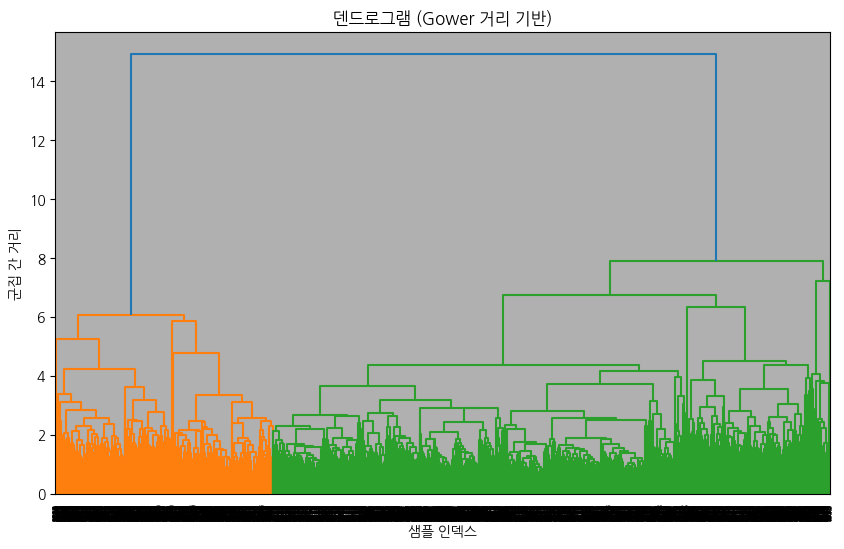

In [13]:
import gower
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
import matplotlib.pyplot as plt
import numpy as np

# ✅ 1. 데이터 준비
best_combo = ['위도', '경도', '이용인원', '1학년 학급당 학생수', '2학년 학급당 학생수', '3학년 학급당 학생수', '4학년 학급당 학생수', '5학년 학급당 학생수', '6학년 학급당 학생수', '특수학급 학급당 학생수', '다문화자녀수']

sample_data = data[best_combo].dropna()

# ✅ 2. Gower 거리 계산
dist = gower.gower_matrix(sample_data)
dist = np.nan_to_num(dist, nan=1.0, posinf=1.0, neginf=1.0)

# ✅ 3. 계층적 클러스터링
linked = linkage(dist, method='average')
labels = fcluster(linked, t=3, criterion='maxclust')

# ✅ 4. 클러스터 결과 저장
data = data.loc[sample_data.index].copy()
data["cluster"] = labels

print("\n📊 군집별 샘플 수:")
print(data["cluster"].value_counts())

# ✅ 5. 덴드로그램 시각화
plt.figure(figsize=(10, 6))
dendrogram(linked)
plt.title("덴드로그램 (Gower 거리 기반)")
plt.xlabel("샘플 인덱스")
plt.ylabel("군집 간 거리")
plt.grid(True)
plt.show()


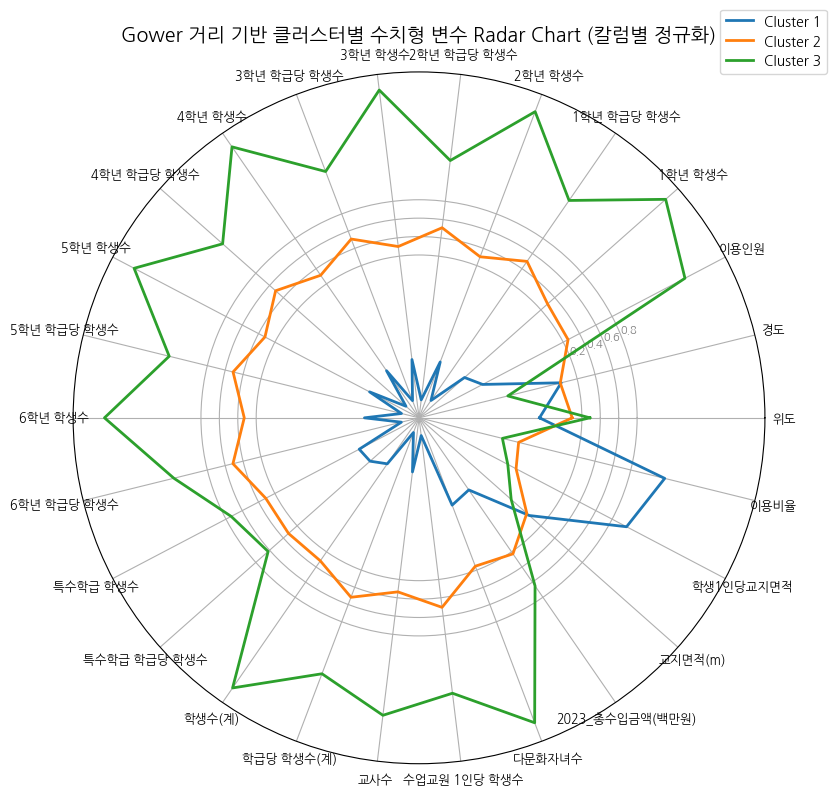

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 수치형 변수만 추출
numeric_cols = data.select_dtypes(include=["int64", "float64"]).columns
numeric_cols = [col for col in numeric_cols if col != "cluster"]

# 2. 수치형 변수만 따로 저장
data_numeric = data[numeric_cols]


# 3. 칼럼별로 표준화 (Standardization: 평균 0, 표준편차 1)
data_normalized = (data_numeric - data_numeric.mean()) / data_numeric.std()

# 4. 정규화된 데이터에 cluster 붙이기
data_normalized["cluster"] = data["cluster"].values

# 5. 군집별 평균 계산
cluster_means_norm = data_normalized.groupby("cluster").mean()

# 6. Radar Chart 그리기
labels = cluster_means_norm.columns.tolist()
labels.remove("cluster") if "cluster" in labels else None  # 혹시 cluster가 남아있으면 제거
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(10, 8))
for i, row in cluster_means_norm.iterrows():
    values = row[labels].tolist()
    values += values[:1]
    plt.polar(angles, values, label=f'Cluster {i}', linewidth=2)

plt.xticks(angles[:-1], labels, fontsize=9)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color="gray", size=8)
plt.title("Gower 거리 기반 클러스터별 수치형 변수 Radar Chart (칼럼별 정규화)", size=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.tight_layout()
plt.show()


cluster         1      2      3
시도교육청                          
강원특별자치도교육청  56.53  43.18   0.28
경기도교육청      12.58  83.81   3.61
경상남도교육청     35.59  64.21   0.20
경상북도교육청     49.37  50.42   0.21
광주광역시교육청     8.16  91.84   0.00
대구광역시교육청     2.16  95.24   2.60
대전광역시교육청    10.07  88.59   1.34
부산광역시교육청     6.35  91.64   2.01
서울특별시교육청     1.00  93.14   5.85
울산광역시교육청     7.44  92.56   0.00
인천광역시교육청     8.02  82.06   9.92
전라남도교육청     59.20  40.33   0.47
전북특별자치도교육청  54.43  45.57   0.00
제주특별자치도교육청  36.84  49.12  14.04
충청남도교육청     50.49  49.03   0.49
충청북도교육청     45.95  53.28   0.77


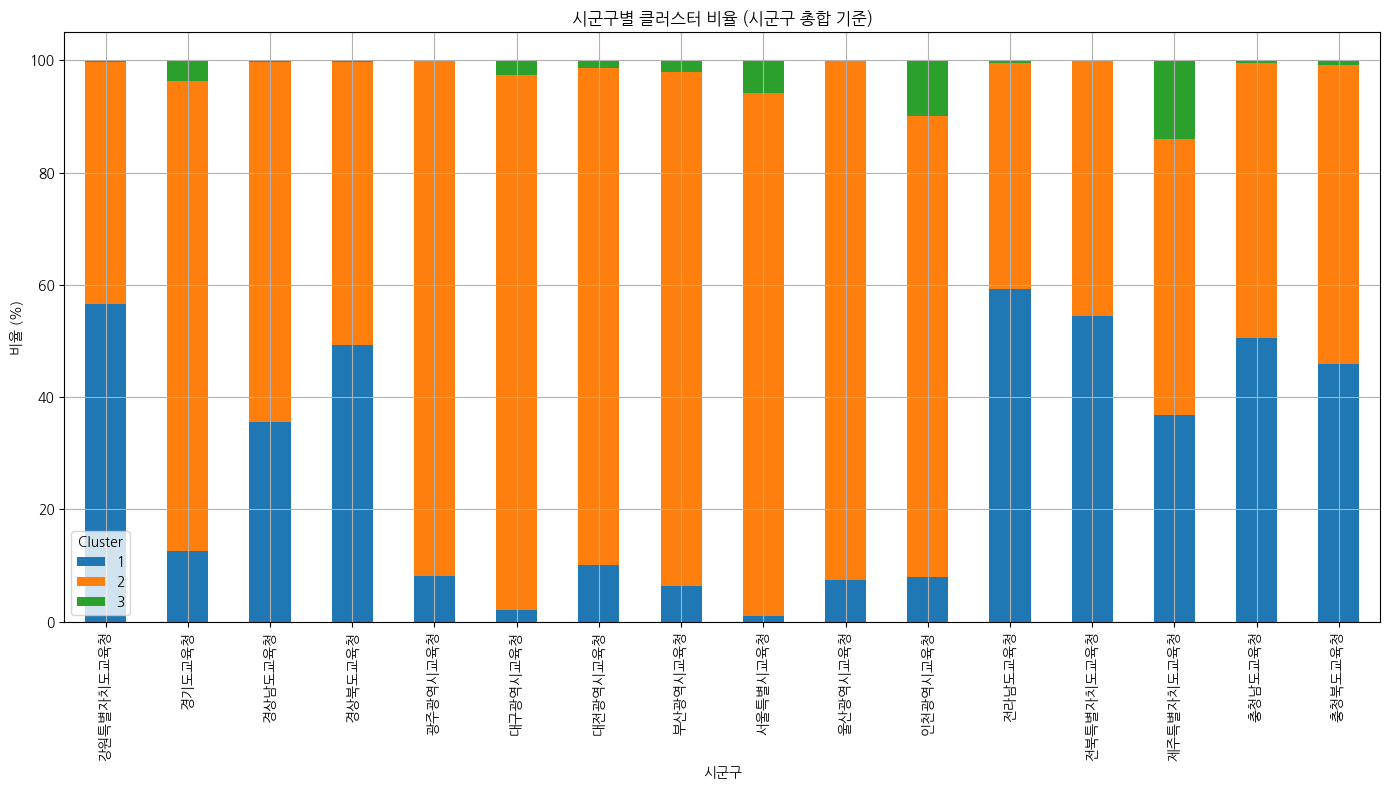

In [15]:
# 1. 시군구별 클러스터 수 세기
region_cluster_counts = data.groupby(["시도교육청", "cluster"]).size().unstack(fill_value=0)

# 2. 시군구별 총합 (시군구별 샘플 수)
region_total = region_cluster_counts.sum(axis=1)

# 3. 시군구별 클러스터 비율 계산
region_cluster_percent = region_cluster_counts.div(region_total, axis=0) * 100

# 4. 결과 출력
print(region_cluster_percent.round(2))  # 보기 좋게 소수점 2자리로

# 5. 필요하면 시각화
import matplotlib.pyplot as plt

region_cluster_percent.plot(kind="bar", stacked=True, figsize=(14, 8))
plt.title("시군구별 클러스터 비율 (시군구 총합 기준)")
plt.ylabel("비율 (%)")
plt.xlabel("시군구")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

